In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
# Wczytanie danych
normal = pd.read_excel("Przebieg normalny.xlsx")
disturbed = pd.read_excel("Przebieg zaburzony.xlsx")

# Sygnały
y = normal["y (T)"].values
u = normal["u (Pg)"].values
z = normal["z (Tz)"].values

y_d = disturbed["y (T)"].values
u_d = disturbed["u (Pg)"].values
z_d = disturbed["z (Tz)"].values

# Krok czasowy
dt = normal["Time"].iloc[1] - normal["Time"].iloc[0]


Zad. (i).2 – identyfikacja MNK parametrów a, b

In [4]:
# Wektor wyjścia
Y = y[1:] - y[:-1]

# Macierz regresji
Phi = np.column_stack([
    u[:-1],
    z[:-1] - y[:-1]
])

# MNK
theta = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ Y
a, b = theta

# Parametry fizyczne
c = dt / a
d = b / a

print("Zidentyfikowane parametry:")
print(f"a = {a:.6f}, b = {b:.6f}")
print(f"c = {c:.4f}, d = {d:.4f}")


Zidentyfikowane parametry:
a = 0.000394, b = 0.000416


TypeError: unsupported format string passed to Timedelta.__format__

Zad. (i).3 – predykcja (horyzont h)

In [5]:
def predict(y, u, z, a, b, h):
    N = len(y)
    y_hat = np.zeros(N)
    y_hat[:h] = y[:h]

    for n in range(h, N):
        y_hat[n] = (
            y_hat[n-1]
            + a * u[n-1]
            + b * (z[n-1] - y_hat[n-1])
        )
    return y_hat


In [12]:
horizons = [1,100,500]
predictions = {}

for h in horizons:
    predictions[h] = predict(y, u, z, a, b, h)


Zad. (i).4 – wykres: rzeczywisty vs predykcja

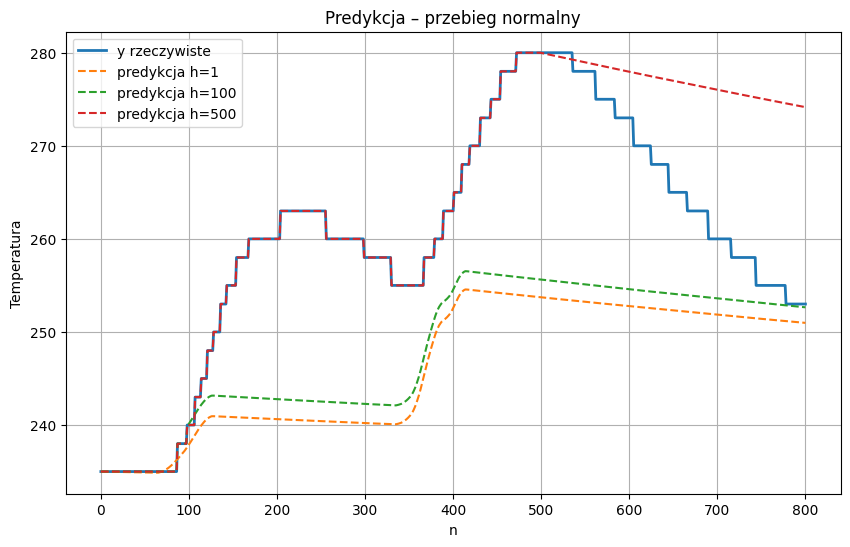

In [13]:
plt.figure(figsize=(10,6))
plt.plot(y, label="y rzeczywiste", linewidth=2)

for h in horizons:
    plt.plot(predictions[h], '--', label=f"predykcja h={h}")

plt.xlabel("n")
plt.ylabel("Temperatura")
plt.legend()
plt.grid()
plt.title("Predykcja – przebieg normalny")
plt.show()


Zad. (ii).1 – reszta predykcji (normalny)

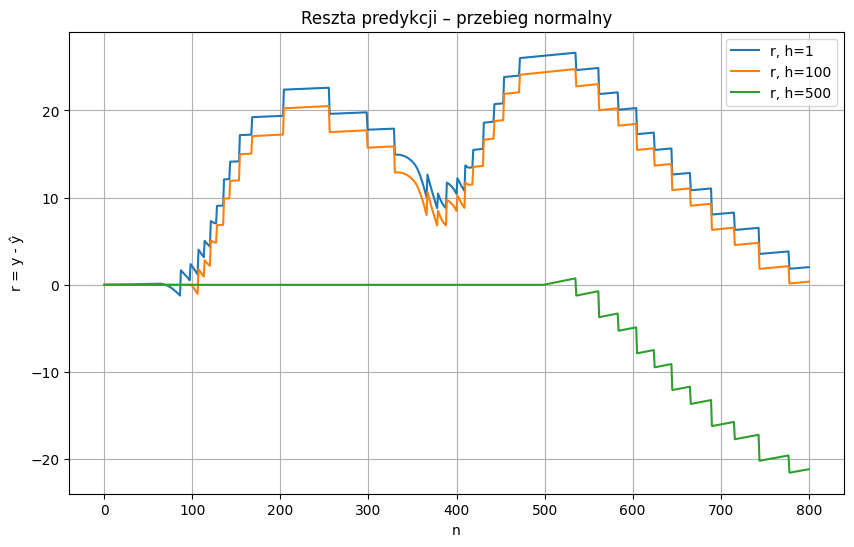

In [14]:
residuals = {}
for h in horizons:
    residuals[h] = y - predictions[h]

plt.figure(figsize=(10,6))
for h in horizons:
    plt.plot(residuals[h], label=f"r, h={h}")

plt.xlabel("n")
plt.ylabel("r = y - ŷ")
plt.legend()
plt.grid()
plt.title("Reszta predykcji – przebieg normalny")
plt.show()


Zad. (ii).2–3 – dane zaburzone

In [15]:
predictions_d = {}
residuals_d = {}

for h in horizons:
    predictions_d[h] = predict(y_d, u_d, z_d, a, b, h)
    residuals_d[h] = y_d - predictions_d[h]


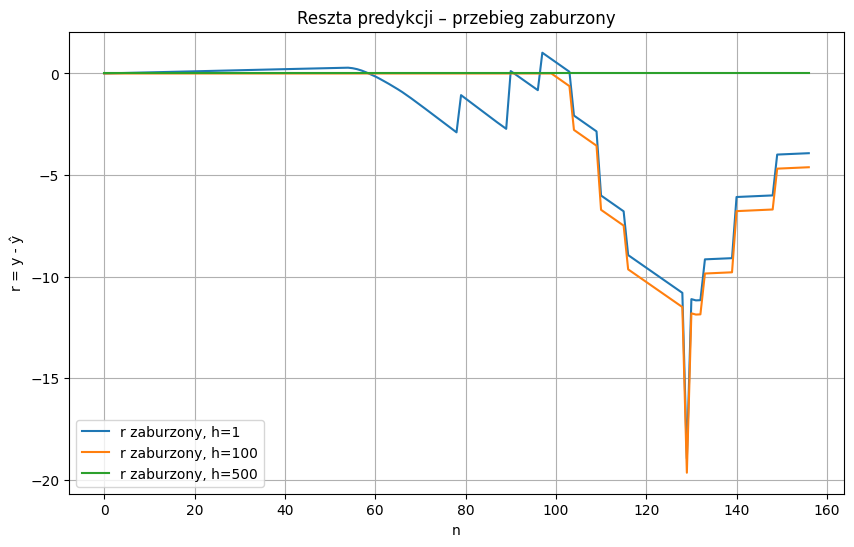

In [16]:
plt.figure(figsize=(10,6))
for h in horizons:
    plt.plot(residuals_d[h], label=f"r zaburzony, h={h}")

plt.xlabel("n")
plt.ylabel("r = y - ŷ")
plt.legend()
plt.grid()
plt.title("Reszta predykcji – przebieg zaburzony")
plt.show()


Zad. (ii).4–5 – próg detekcji (σ)

In [17]:
for h in horizons:
    mu = np.mean(residuals[h])
    sigma = np.std(residuals[h], ddof=1)
    print(f"h={h}: σ = {sigma:.4f}, próg 3σ = {3*sigma:.4f}")


h=1: σ = 8.4472, próg 3σ = 25.3417
h=100: σ = 8.0560, próg 3σ = 24.1679
h=500: σ = 6.8493, próg 3σ = 20.5478


In [24]:
# Liczba próbek
N = len(y) - 1

theta_hat = np.zeros((2, N))
theta_hat[:, 0] = [a, b]

P = np.eye(2) * 100.0
Q = np.eye(2) * 1e-8
R = np.var(Y)

for n in range(N-1):
    phi = np.array([u[n], z[n] - y[n]])
    dy = y[n+1] - y[n]

    theta_pred = theta_hat[:, n]
    P_pred = P + Q

    e = dy - phi @ theta_pred
    S = phi @ P_pred @ phi.T + R

    K = (P_pred @ phi) / S

    theta_hat[:, n+1] = theta_pred + K * e
    P = (np.eye(2) - np.outer(K, phi)) @ P_pred

a_kf = theta_hat[0]
b_kf = theta_hat[1]

# --- BEZPIECZNE LICZENIE c, d ---
c_kf = np.full_like(a_kf, np.nan)
d_kf = np.full_like(a_kf, np.nan)

valid = np.abs(a_kf) > 1e-6
c_kf[valid] = dt / a_kf[valid]
d_kf[valid] = b_kf[valid] / a_kf[valid]


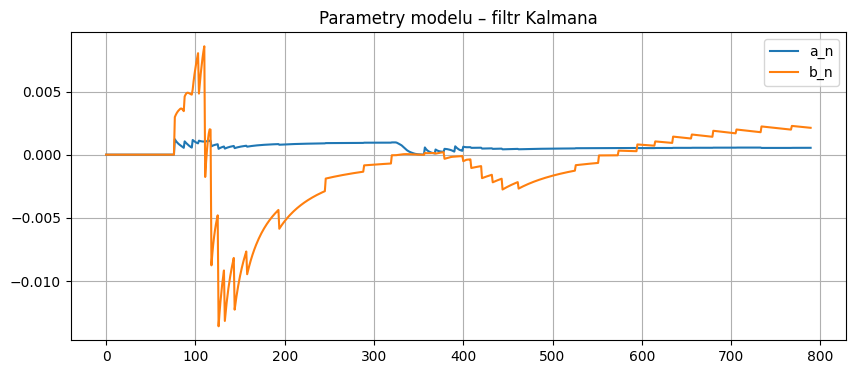

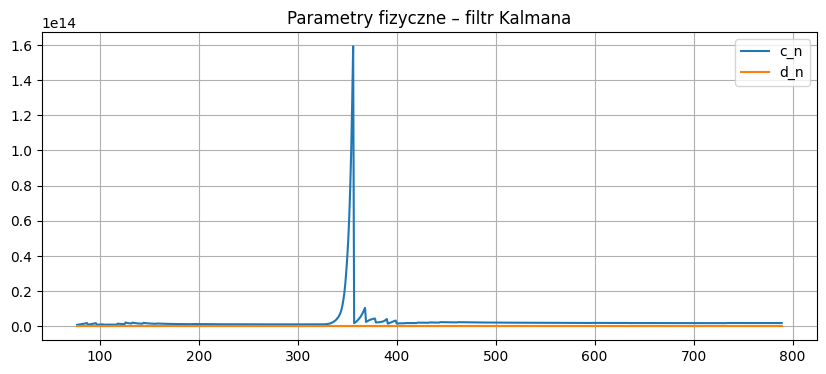

In [26]:

n0 = 10

plt.figure(figsize=(10,4))
plt.plot(a_kf[n0:], label="a_n")
plt.plot(b_kf[n0:], label="b_n")
plt.legend()
plt.grid()
plt.title("Parametry modelu – filtr Kalmana")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(c_kf[n0:], label="c_n")
plt.plot(d_kf[n0:], label="d_n")
plt.legend()
plt.grid()
plt.title("Parametry fizyczne – filtr Kalmana")
plt.show()
